In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pickle

In [29]:
df = pd.read_csv(r'C:\Users\miguel\Documents\datasets\insurance.csv')
df.head(30)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [24]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


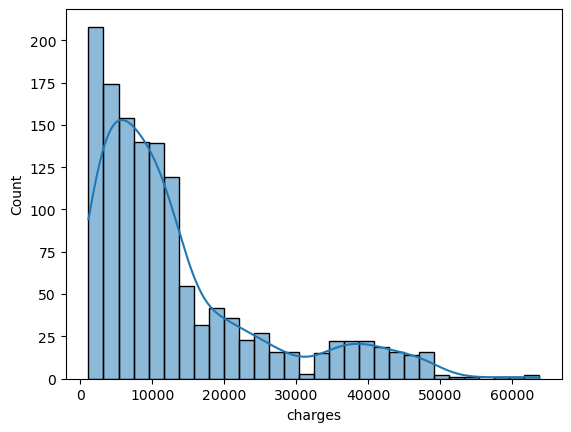

In [25]:
sns.histplot(df['charges'], kde=True)
plt.show()


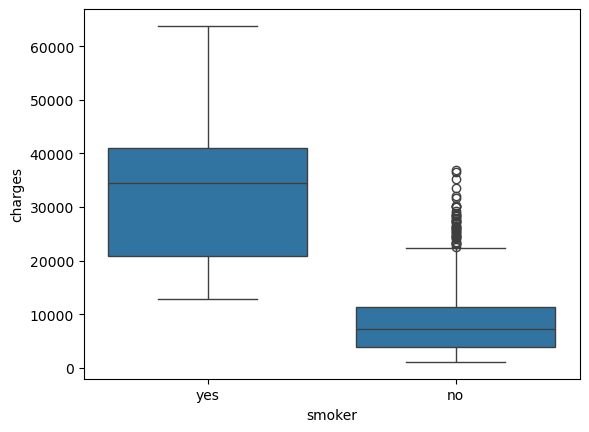

In [26]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()


In [28]:
# PRÉ PROCESSAMENTO

df = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)
df.head()


KeyError: "None of [Index(['sex', 'smoker', 'region'], dtype='object')] are in the [columns]"

In [20]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['age', 'bmi', 'children']] = scaler.fit_transform(df[['age', 'bmi', 'children']])


Text(0.5, 1.0, 'Como a Idade x valor')

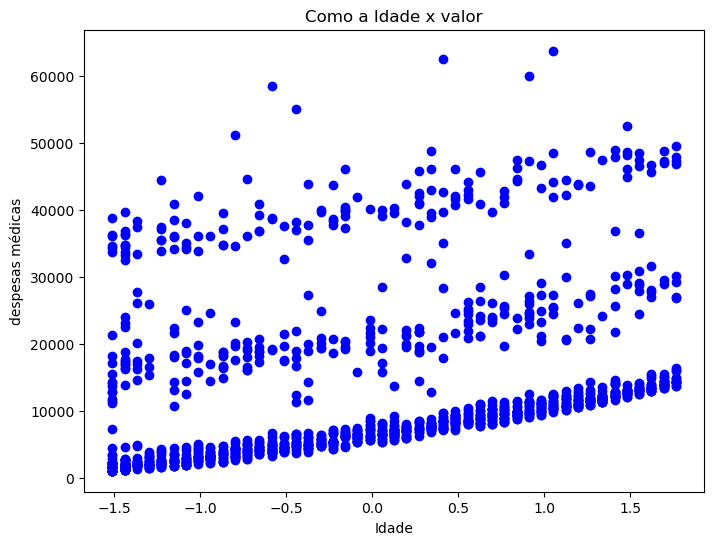

In [9]:
plt.figure(figsize=(8, 6))

# Usando plt.scatter para fazer um gráfico de dispersão
plt.scatter(df['age'], df['charges'], color='blue')

# Ajustando os rótulos
plt.xlabel('Idade')
plt.ylabel('despesas médicas')
plt.title('Como a Idade x valor')

In [10]:
from sklearn.model_selection import train_test_split
X = df.drop(columns='charges')
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [12]:
# Especifique o caminho onde deseja salvar o modelo e o scaler
caminho_modelo = 'C:/Users/miguel/Desktop/Regressao Linear Insurance/modelo.pkl'
caminho_scaler = 'C:/Users/miguel/Desktop/Regressao Linear Insurance/scaler.pkl'

# Salvando o modelo treinado no arquivo .pkl
with open(caminho_modelo, 'wb') as arquivo:
    pickle.dump(model, arquivo)

# Salvando o scaler no arquivo .pkl separado
with open(caminho_scaler, 'wb') as f:
    pickle.dump(scaler, f)

print(f"Modelo salvo com sucesso em: {caminho_modelo}")
print(f"Scaler salvo com sucesso em: {caminho_scaler}")



Modelo salvo com sucesso em: C:/Users/miguel/Desktop/Regressao Linear Insurance/modelo.pkl
Scaler salvo com sucesso em: C:/Users/miguel/Desktop/Regressao Linear Insurance/scaler.pkl


In [13]:
y_pred = model.predict(X_test)


In [14]:
print(y_pred)

[ 8969.55027444  7068.74744287 36858.41091155  9454.67850053
 26973.17345656 10864.11316424   170.28084136 16903.45028662
  1092.43093614 11218.34318352 28101.68455267  9377.73460205
  5263.0595179  38416.04221107 40255.82339284 37098.25353123
 15240.39392306 35912.88264434  9112.52398703 31461.92108909
  3847.68845883 10130.12001517  2370.54189389  7140.21550828
 11301.76782638 12961.65366224 14509.47251876  6159.8976107
  9963.85857263  2177.85718217  9115.93673493 13073.68932159
  4561.82376202  3408.20756033  4459.81359745 13032.06505076
  1979.99357292  8813.28303302 33271.29124448 32585.51583927
  3908.76090964  4326.10774721 14142.81326533 11423.45494846
  8774.13955311 12097.28051001  5281.57353499  3150.5596042
 35494.46461214  9150.1124786  15836.84575621  2343.57470069
 12364.78414194  1482.29488266 13389.06105161 12573.57395972
  4341.83680558 32165.33688042 13321.3360032  12896.82071102
 14167.99421483 10506.17623512 16360.78543548  7763.89824584
 11839.25019431  4061.1975

In [15]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MSE: {mse}, RMSE: {rmse}, R²: {r2}")


MSE: 33596915.85136147, RMSE: 5796.2846592762735, R²: 0.7835929767120723


In [16]:
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_}))


            Feature   Coefficient
0               age   3609.149018
1               bmi   2054.885063
2          children    512.478869
3          sex_male    -18.591692
4        smoker_yes  23651.128856
5  region_northwest   -370.677326
6  region_southeast   -657.864297
7  region_southwest   -809.799354


In [ ]:
input_data = {
    'age': 28,
    'bmi': 33.0,
    'children': 3,
    'sex_male': 1,  # já que é female
    'smoker_yes': 0,  # já que é no
    'region_northwest': 0,  # região "northwest"
    'region_southeast': 1,
    'region_southwest': 0
}

# Crie um DataFrame com as colunas corretas e a ordem correspondente
input_df = pd.DataFrame([input_data], columns=model.feature_names_in_)


In [ ]:
# Fazer a previsão
predicted_charge = model.predict(input_df)[0]

# Mostrar o valor estimado
print(f"Valor estimado do seguro: {predicted_charge:.2f}")
